In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [11]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [12]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [13]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [14]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [15]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [16]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 105 concetti unici e 4432 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 0.3043
Epoca [10/100] | Loss: 0.0546
Epoca [20/100] | Loss: 0.0176
Epoca [30/100] | Loss: 0.0056
Epoca [40/100] | Loss: 0.0029
Epoca [50/100] | Loss: 0.0018
Epoca [60/100] | Loss: 0.0014
Epoca [70/100] | Loss: 0.0012
Epoca [80/100] | Loss: 0.0010
Epoca [90/100] | Loss: 0.0010
Epoca [100/100] | Loss: 0.0009

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | active
 - P_teorica: 1.0 -> P_predetta: 0.9995
Relazione: meat | oldworld
 - P_teorica: 0.0 -> P_predetta: 0.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [17]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

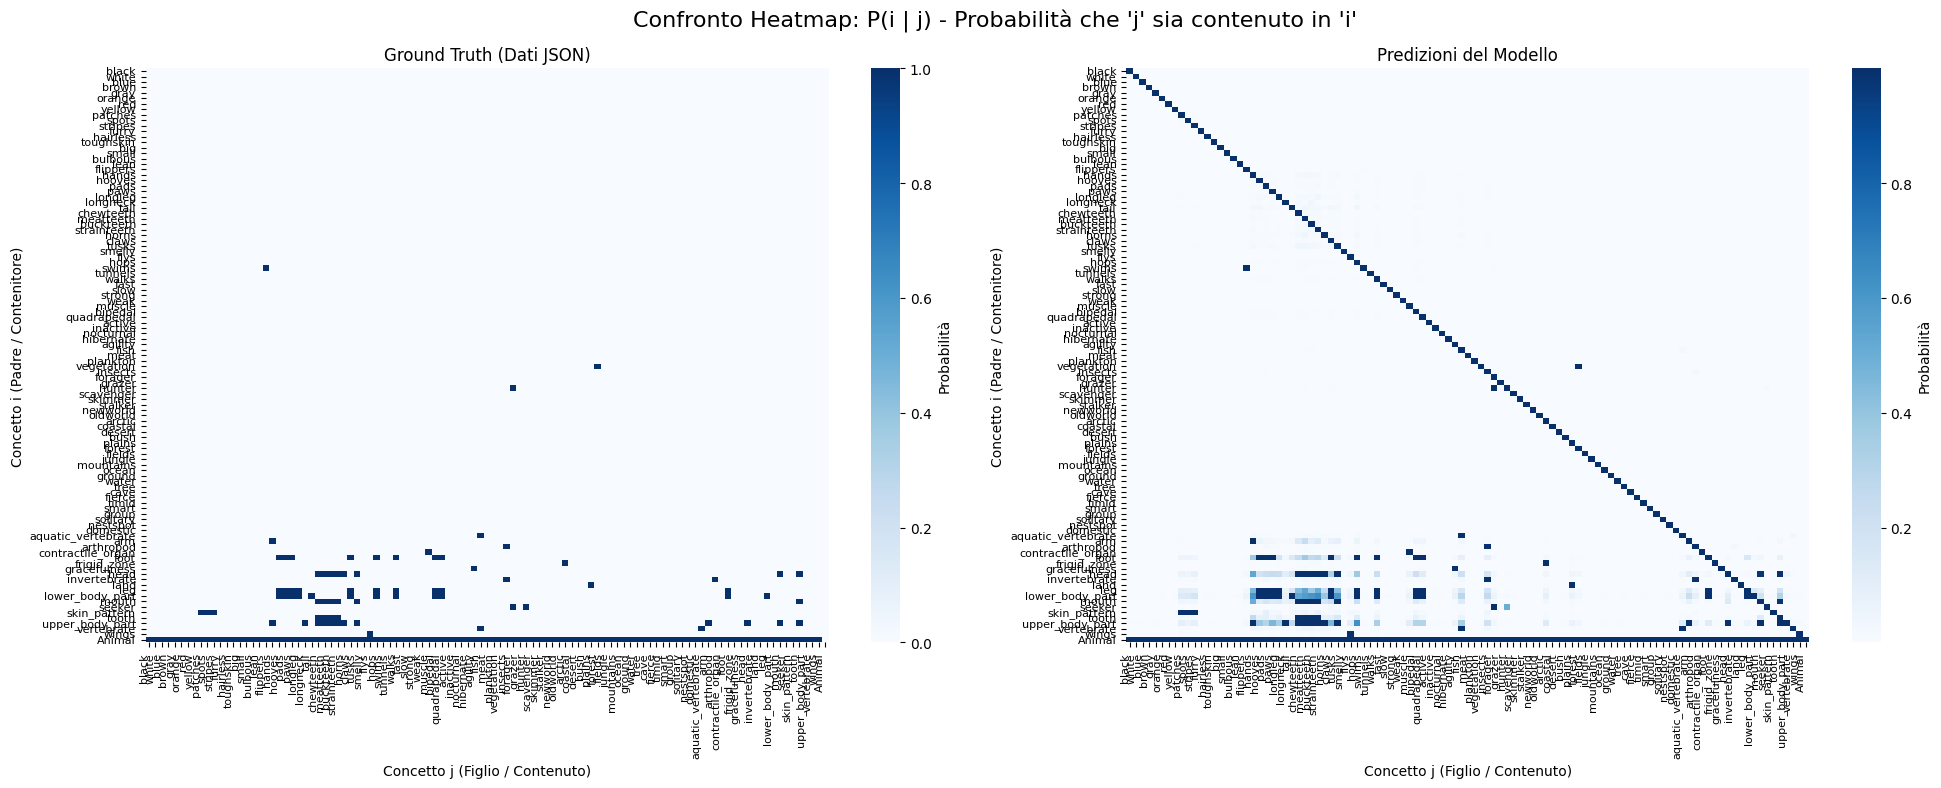

In [18]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

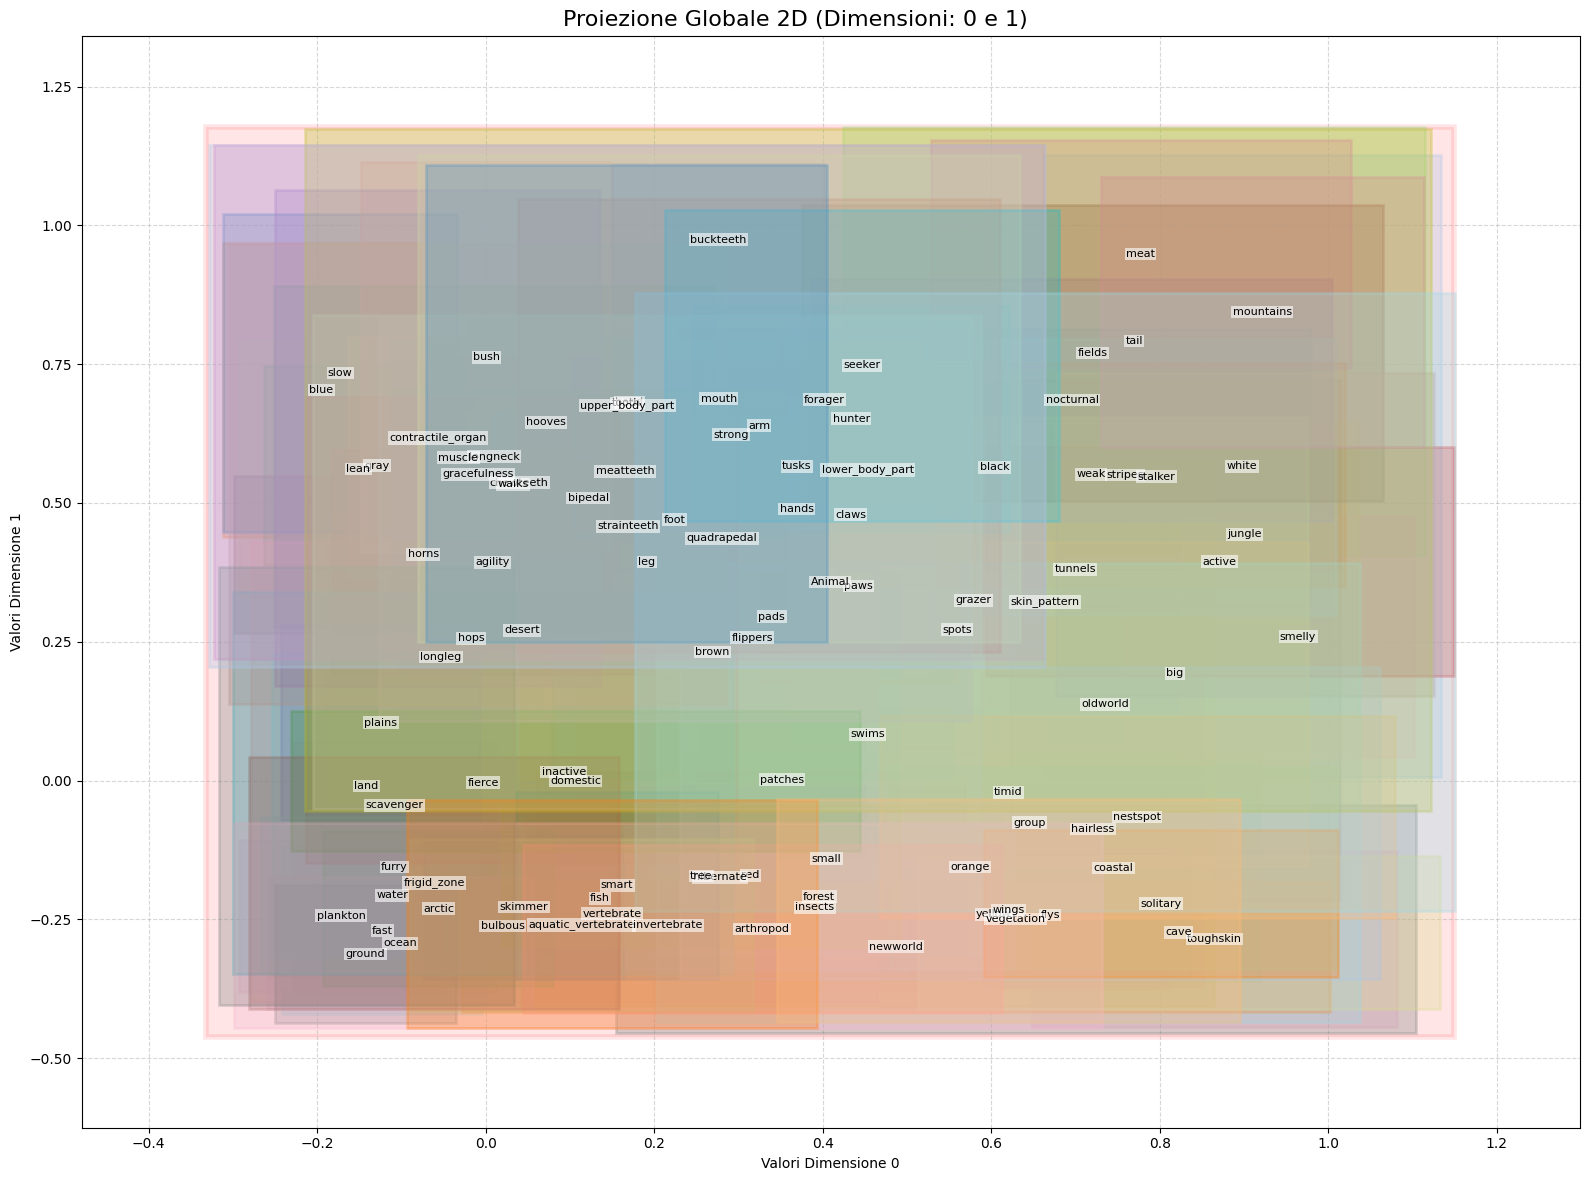

In [19]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

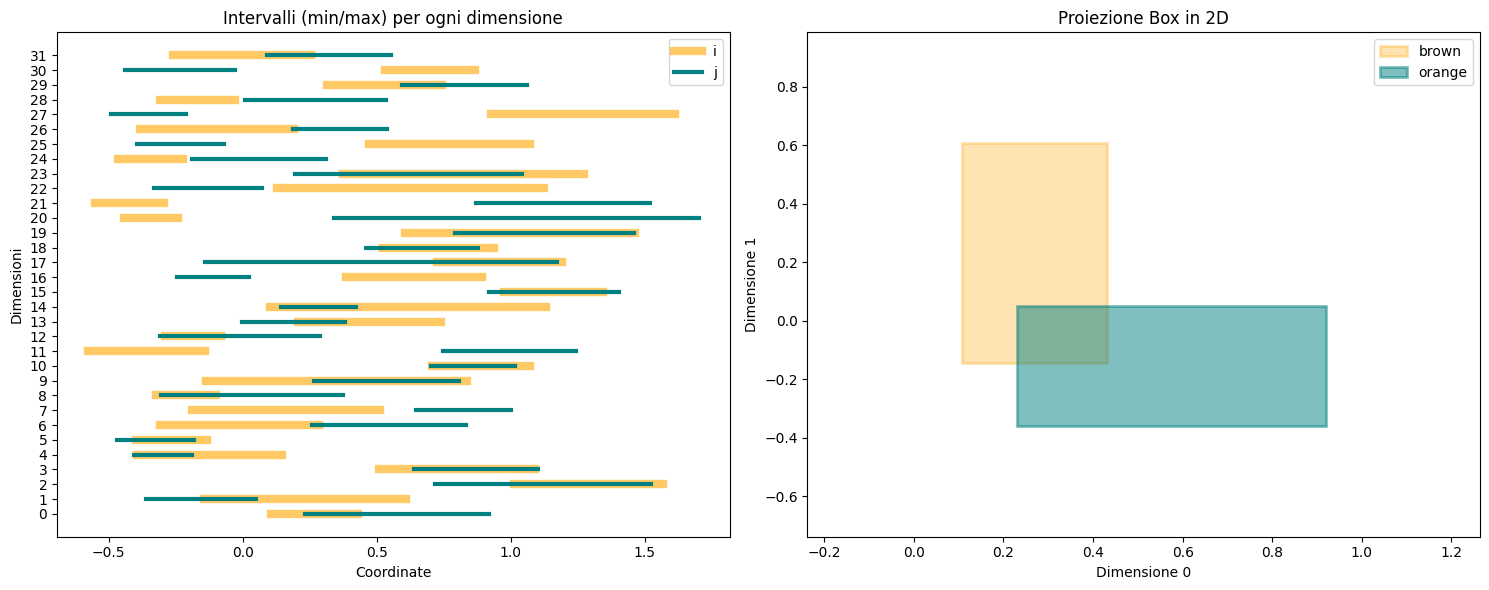

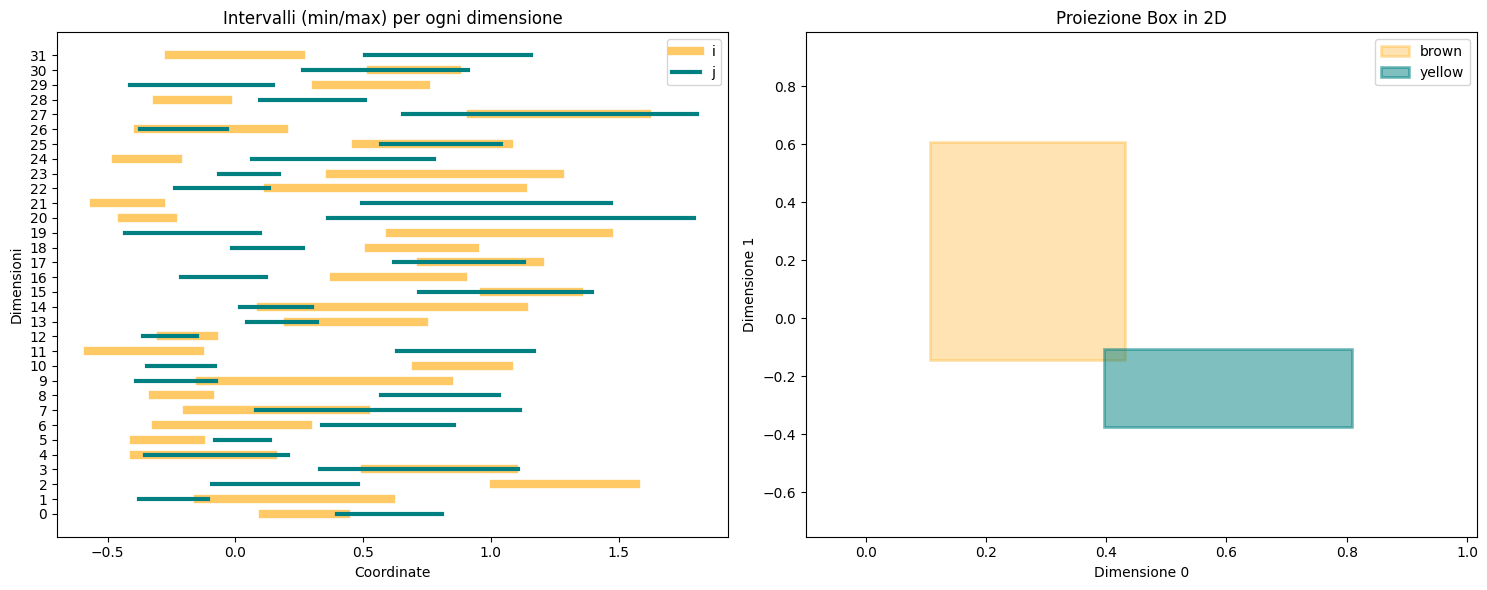

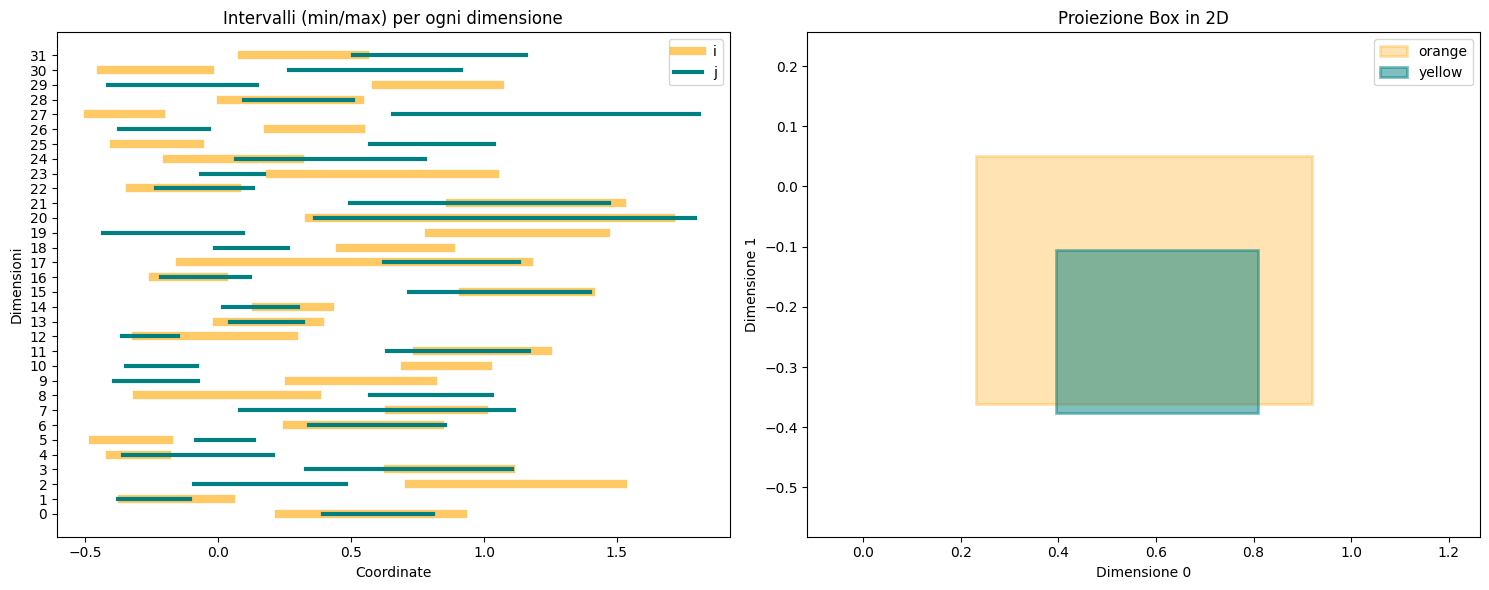

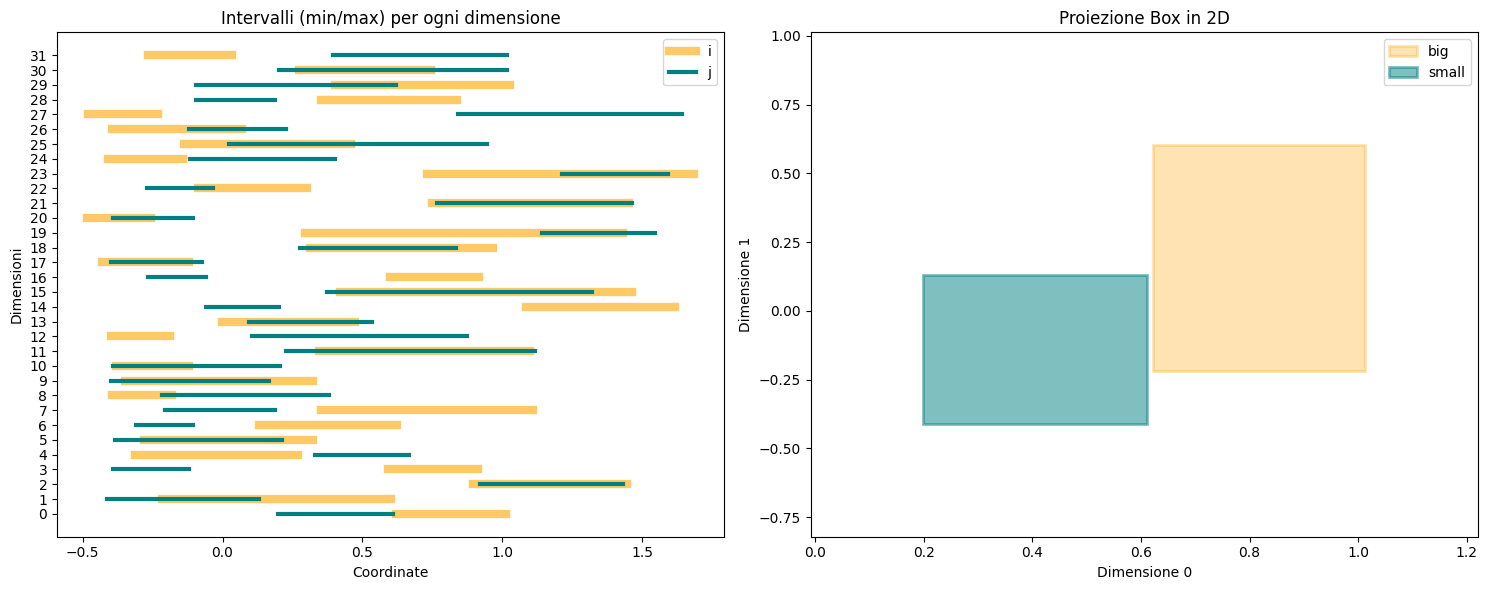

In [20]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [21]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [22]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [23]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [24]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [25]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [26]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [27]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.040, Acc=99.3% | VAL: Loss=0.000, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

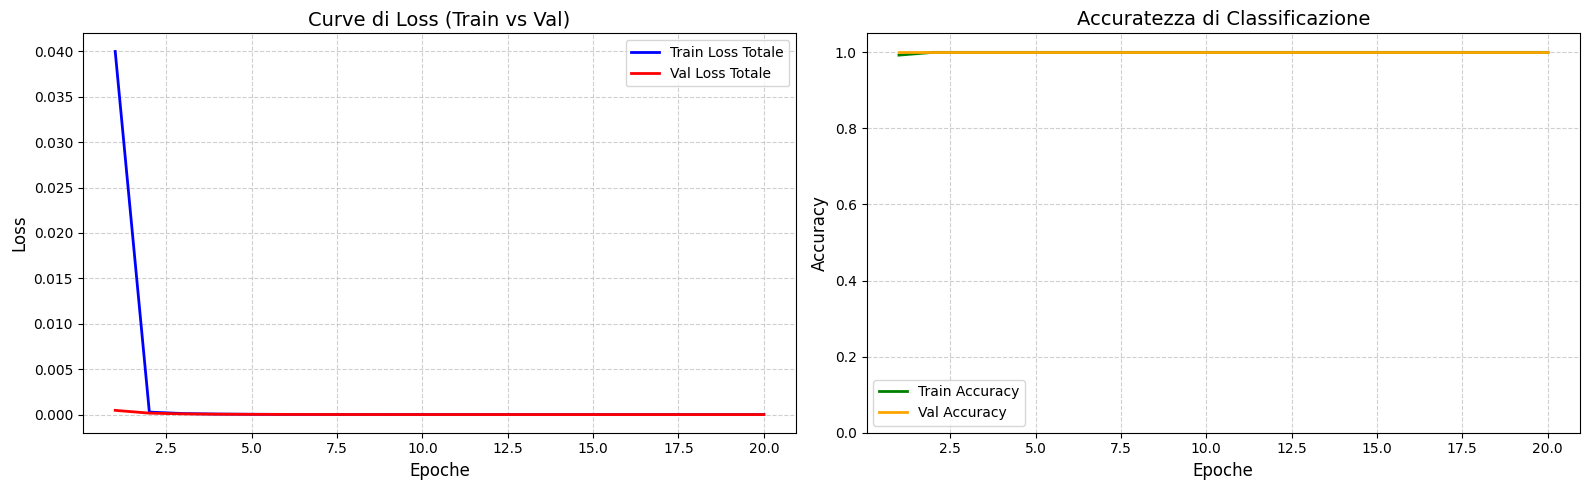

In [28]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [29]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


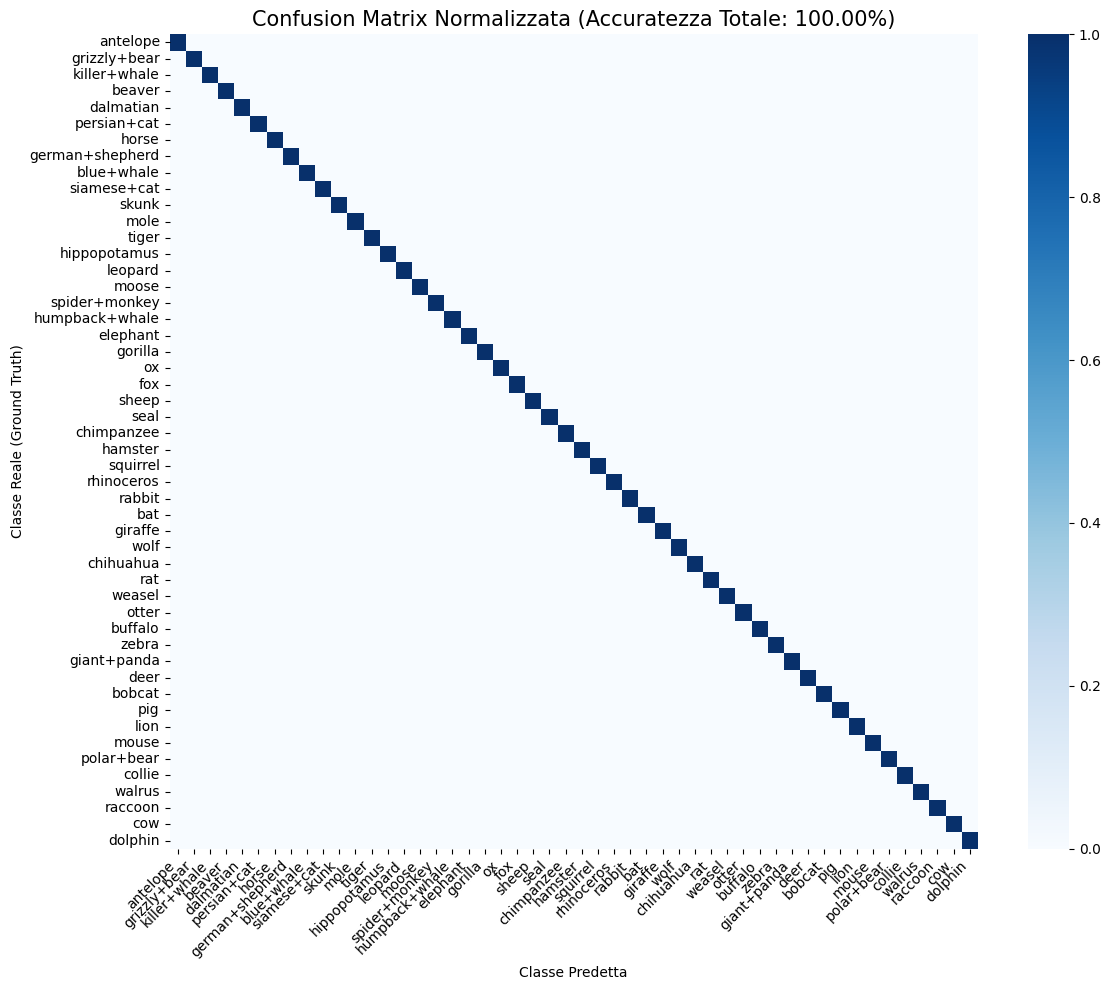


Analisi degli Errori Principali:


In [30]:
plot_test_results(accuracy, preds, labels, class_names=classes)

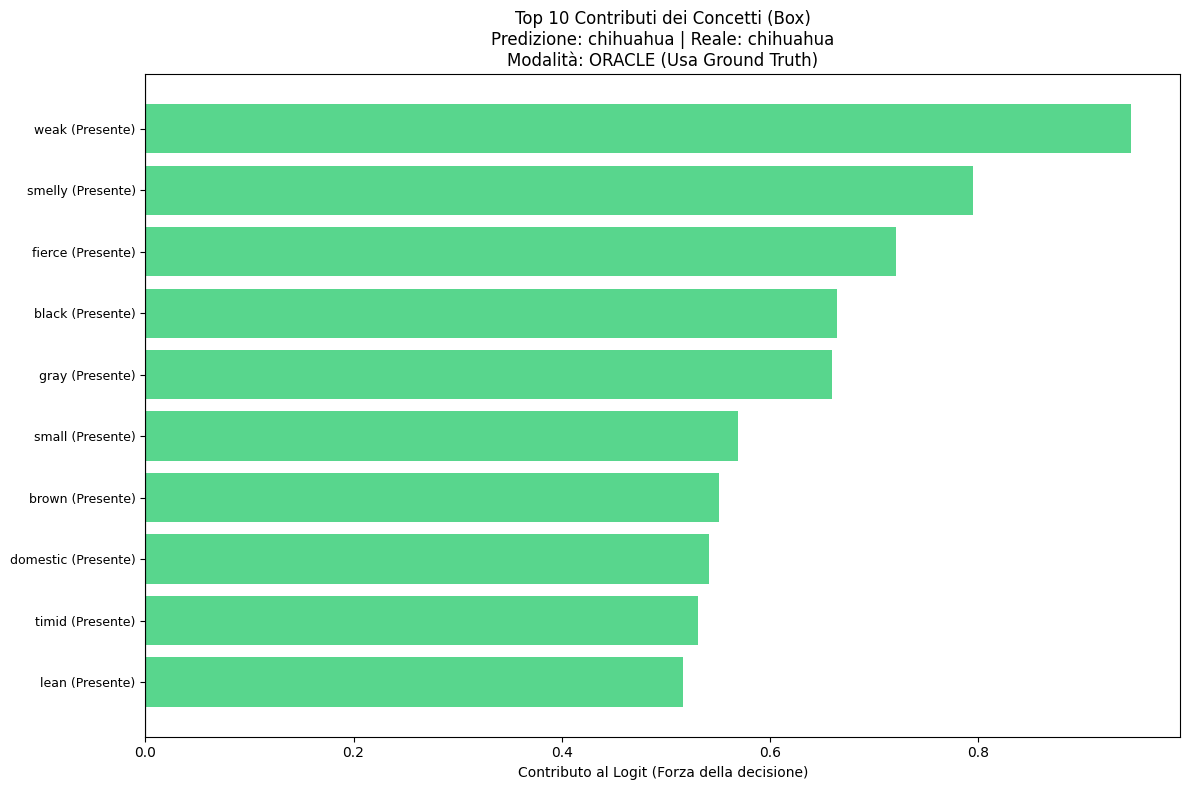

True

In [31]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [32]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.249, Acc=97.7% | VAL: Loss=0.013, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

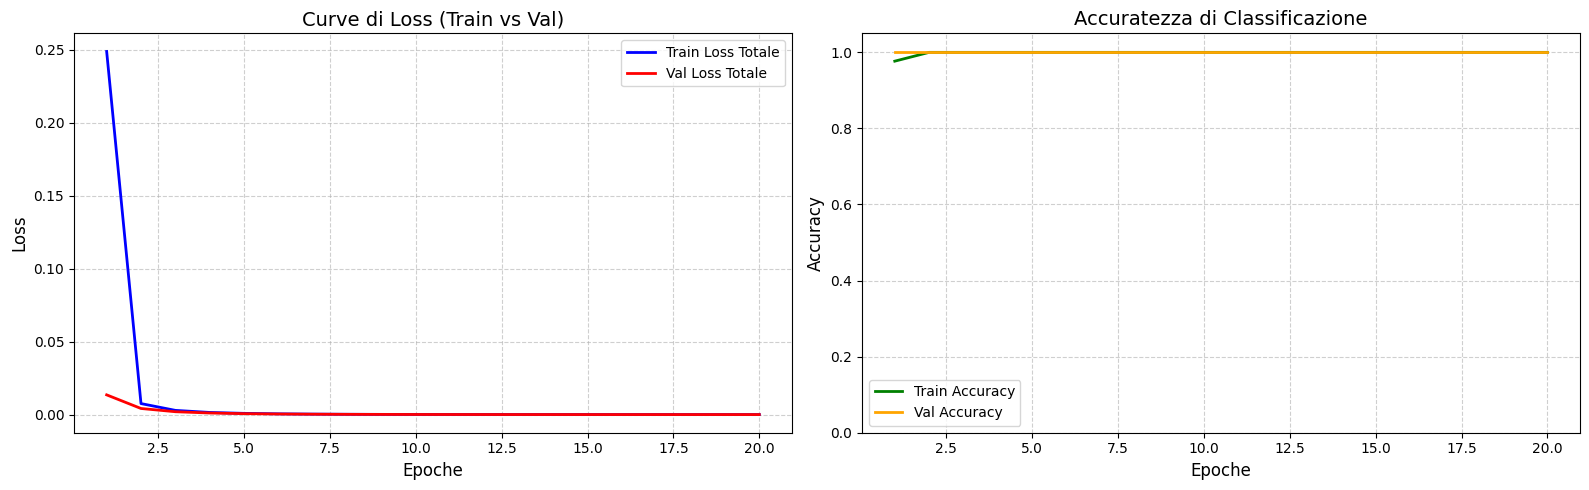

In [33]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [34]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


ValueError: too many values to unpack (expected 5)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [35]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.737, Acc=93.2% | VAL: Loss=0.083, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.044, Acc=100.0% | VAL: Loss=0.024, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.016, Acc=100.0% | VAL: Loss=0.011, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.006, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

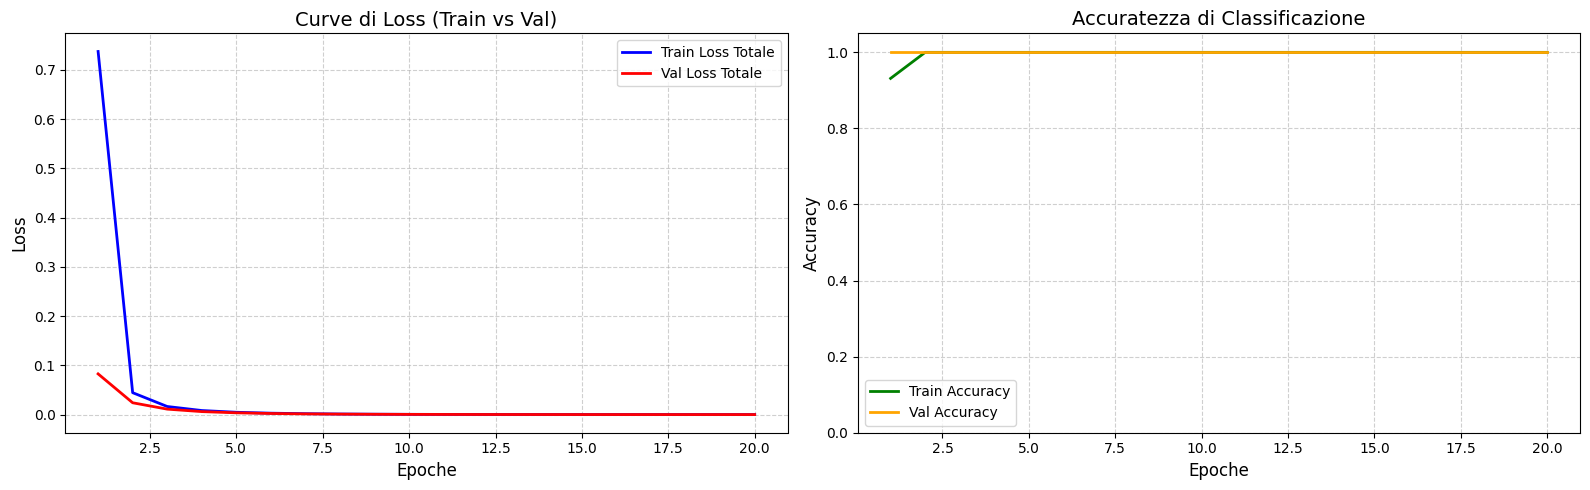

In [36]:
from src.utils.plot import plot_history
plot_history(c_history)

In [37]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


ValueError: too many values to unpack (expected 5)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [ ]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [39]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 4.2247 | Acc: 95.1603 || Val Loss: 3.1167 | Val Acc: 96.4221
Loss: 2.7165 | Acc: 96.9087 || Val Loss: 2.7668 | Val Acc: 96.8005
Loss: 2.3679 | Acc: 97.2884 || Val Loss: 2.7099 | Val Acc: 96.8423
Loss: 2.1651 | Acc: 97.5016 || Val Loss: 2.6163 | Val Acc: 96.9745
Loss: 2.0198 | Acc: 97.6749 || Val Loss: 2.5797 | Val Acc: 97.0288
Loss: 1.9159 | Acc: 97.7901 || Val Loss: 2.6436 | Val Acc: 96.9553
Loss: 1.8299 | Acc: 97.9016 || Val Loss: 2.6107 | Val Acc: 97.0311
Loss: 1.7545 | Acc: 97.9755 || Val Loss: 2.5996 | Val Acc: 97.0130
Loss: 1.7004 | Acc: 98.0400 || Val Loss: 2.6550 | Val Acc: 97.0069
Loss: 1.6429 | Acc: 98.1006 || Val Loss: 2.6117 | Val Acc: 97.0791
Loss: 1.5967 | Acc: 98.1601 || Val Loss: 2.6733 | Val Acc: 97.0025
Loss: 1.5599 | Acc: 98.1961 || Val Loss: 2.6752 | Val Acc: 97.0140
Loss: 1.5236 | Acc: 98.2470 || Val Loss: 2.7306 | Val Acc: 97.0041
Loss: 1.4925 | Acc: 98.2808 || Val Loss: 2.7491 | Val Acc: 97.0008
Loss: 1.4591 | Acc: 98.3218 || Val Loss: 2.7602 | Val Acc: 96.

### BOXES

In [40]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 92.08%


#### STATS 

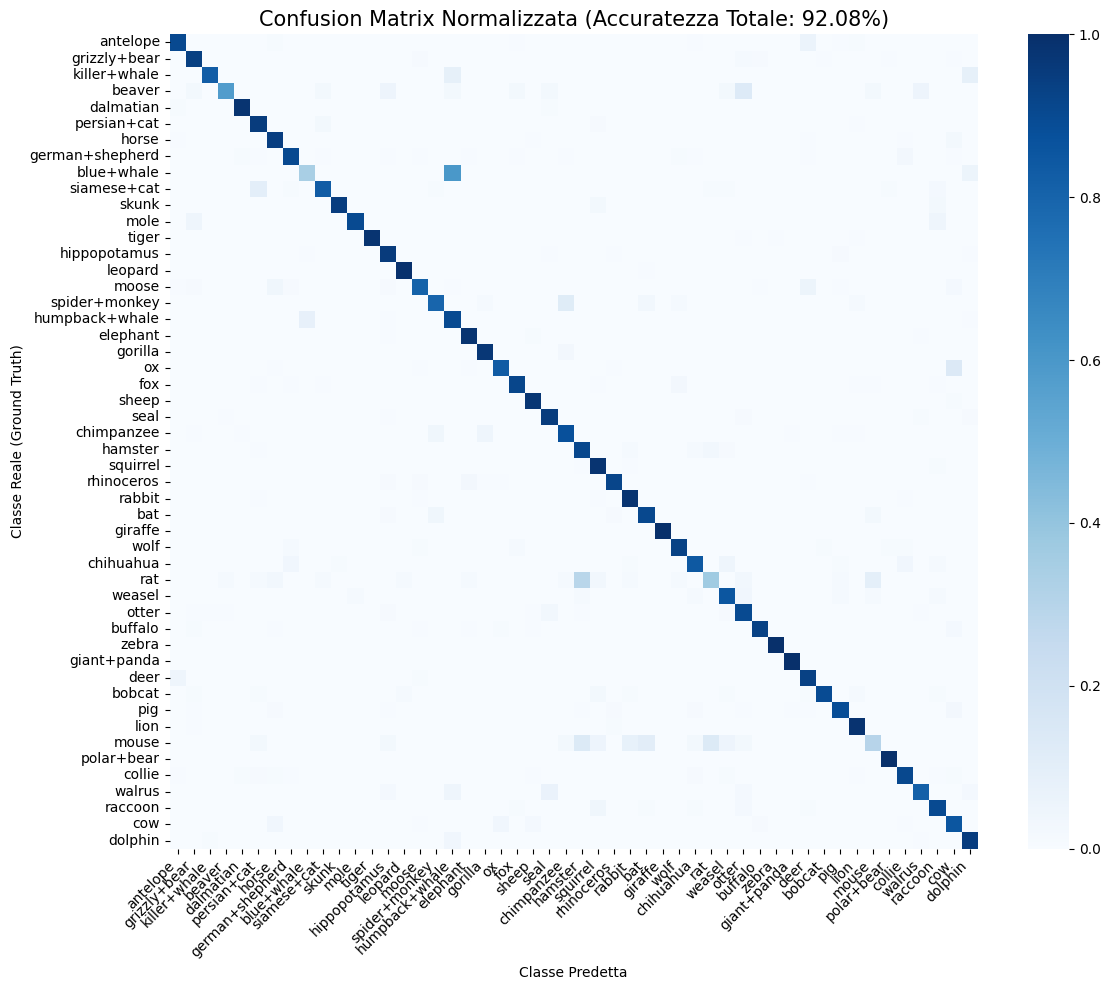


Analisi degli Errori Principali:
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 18 volte: 'rat' è stato scambiato per 'hamster'
 - 13 volte: 'antelope' è stato scambiato per 'deer'
 - 12 volte: 'deer' è stato scambiato per 'antelope'


In [41]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

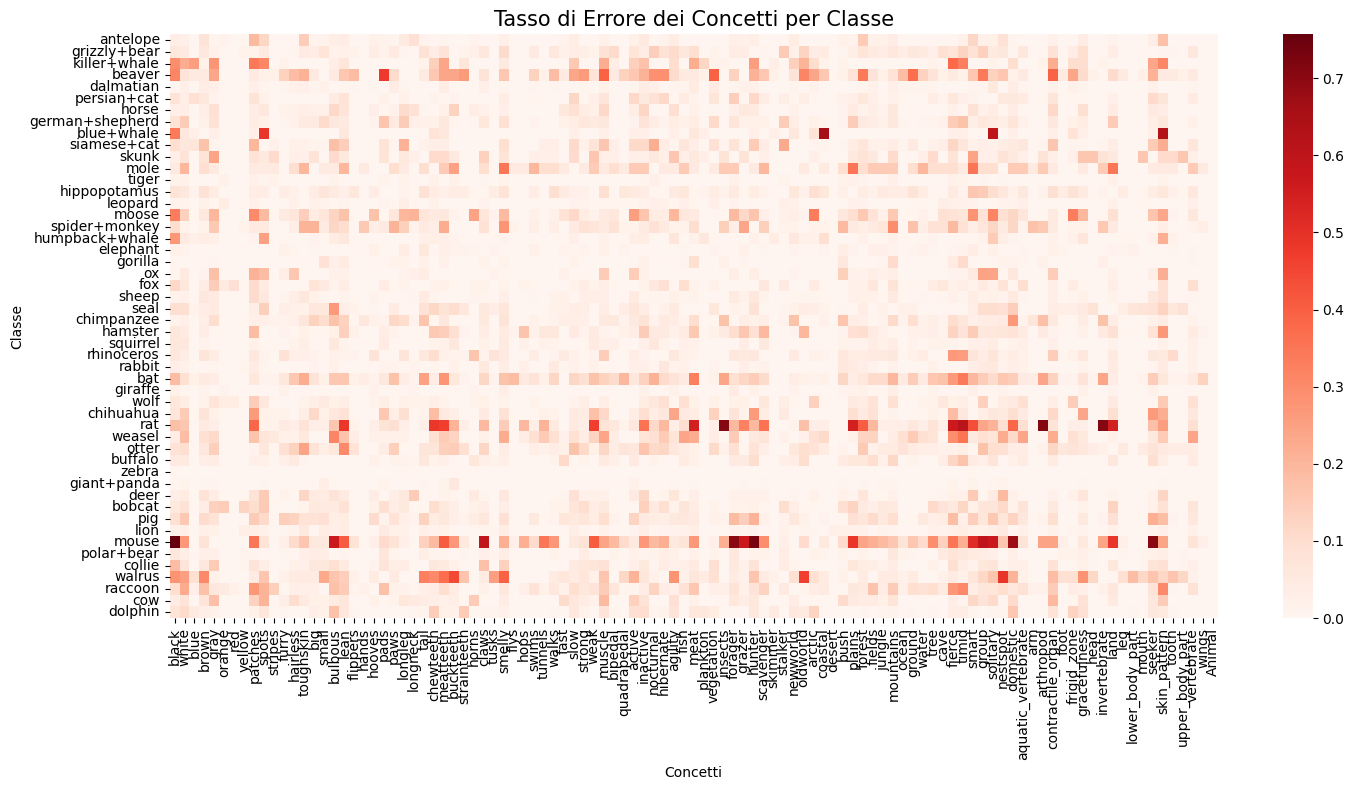

In [42]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [43]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'persian+cat'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [smelly] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [slow] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [weak] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [inactive] Falso Positivo: D

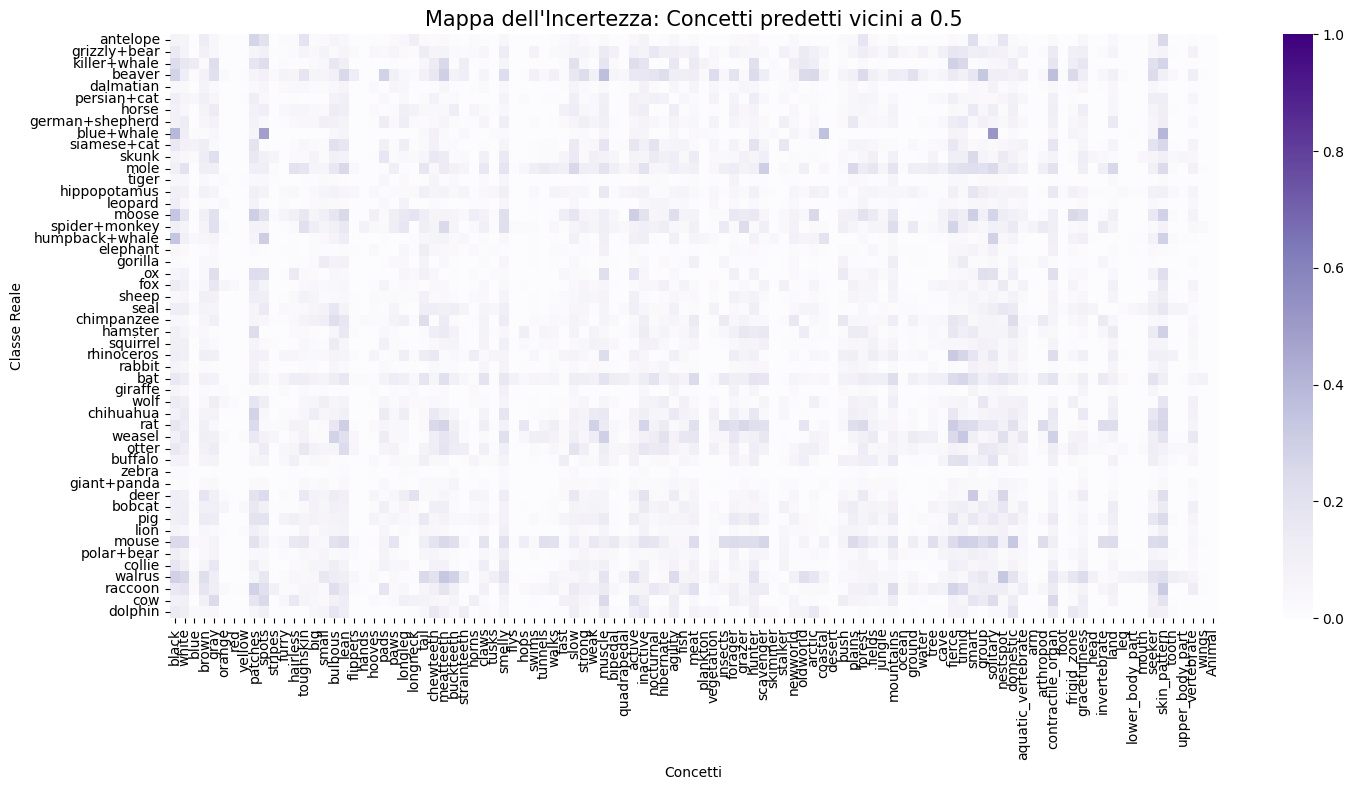

array([[7.23062754e-02, 6.88625053e-02, 1.23619742e-04, ...,
        1.34271160e-02, 4.34600588e-06, 3.42227624e-09],
       [1.51128724e-01, 7.45384246e-02, 1.40990049e-03, ...,
        8.18756074e-02, 3.28141095e-06, 0.00000000e+00],
       [2.29483128e-01, 1.67626396e-01, 1.37665302e-01, ...,
        7.04399263e-03, 7.02862089e-05, 8.22133028e-09],
       ...,
       [1.53290406e-01, 1.81255385e-01, 2.44754534e-02, ...,
        1.28418311e-01, 7.95310549e-03, 2.33743713e-09],
       [8.98496360e-02, 1.02610894e-01, 1.60114985e-04, ...,
        6.83239242e-03, 1.94671429e-06, 7.11697234e-09],
       [1.44276783e-01, 1.17985681e-01, 2.68673059e-02, ...,
        7.47643271e-03, 9.03194887e-04, 1.38762140e-08]])

In [44]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION


--- Valutazione con k=0 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.08%
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.08%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.43%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.43%

--- Valutazione con k=1 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.24%
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.74%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.63%
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.20%

--- Valutazione con k=2 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.50%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.65%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.80%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.06%

--- Valutazione con k=3 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.69%
Inizio valutazione su

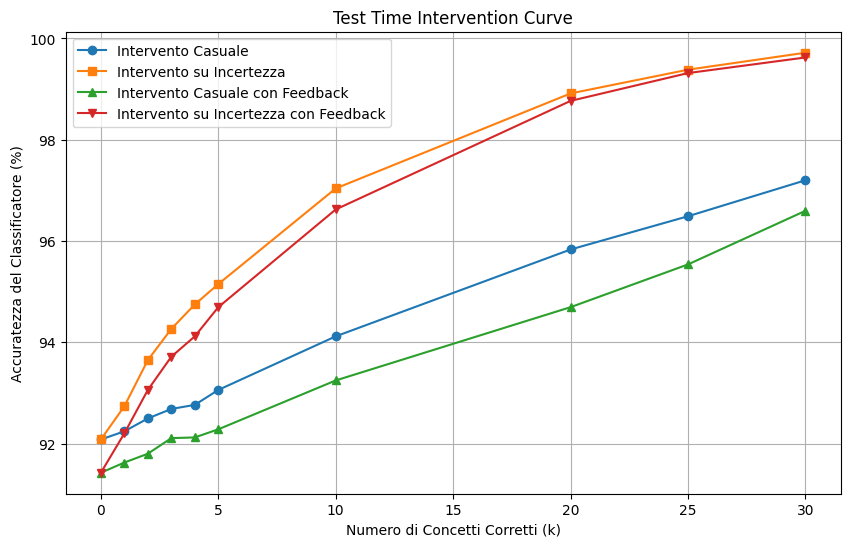

In [45]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [47]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 86.15%


In [57]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=False
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.75%


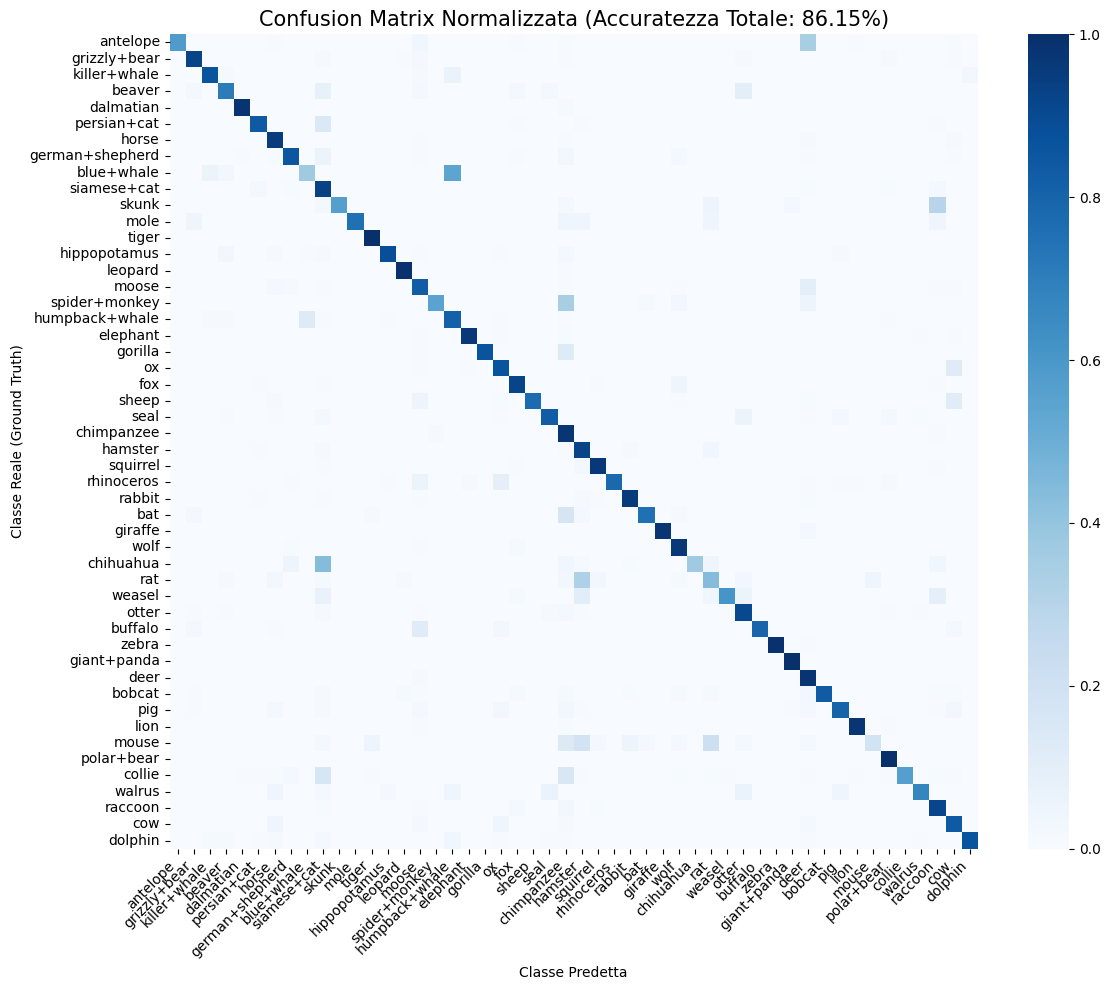


Analisi degli Errori Principali:
 - 72 volte: 'antelope' è stato scambiato per 'deer'
 - 49 volte: 'chihuahua' è stato scambiato per 'siamese+cat'
 - 34 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 33 volte: 'sheep' è stato scambiato per 'cow'
 - 32 volte: 'collie' è stato scambiato per 'chimpanzee'


In [48]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [50]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 92.04%


In [60]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.45%


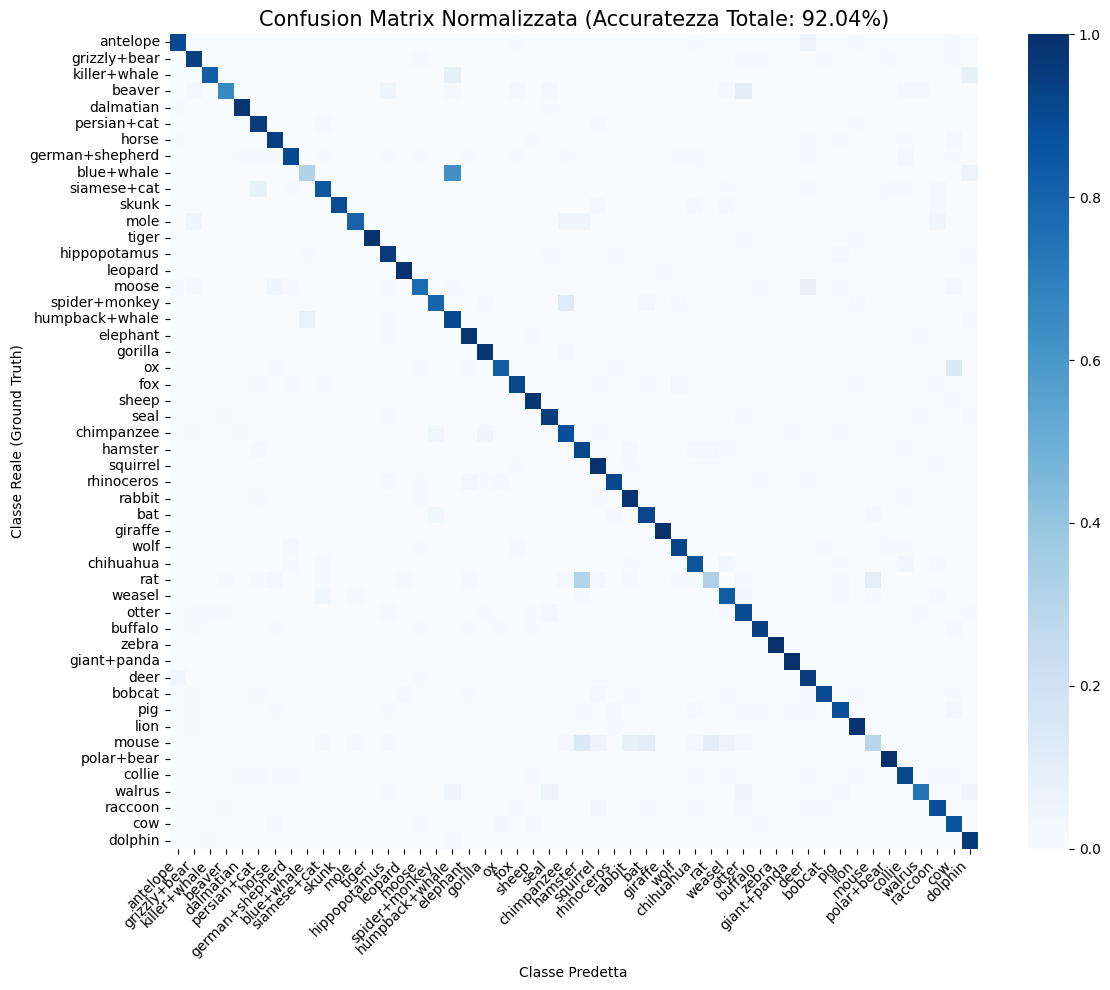


Analisi degli Errori Principali:
 - 22 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 21 volte: 'ox' è stato scambiato per 'cow'
 - 19 volte: 'rat' è stato scambiato per 'hamster'
 - 14 volte: 'antelope' è stato scambiato per 'deer'
 - 11 volte: 'moose' è stato scambiato per 'deer'


In [51]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)